### `list_attr_celeba` Dataset
A popular component of computer vision and deep learning revolves around identifying faces for various applications from logging into your phone with your face or searching through surveillance images for a particular suspect. This dataset is great for training and testing models for face detection, particularly for recognising facial attributes such as finding people with brown hair, are smiling, or wearing glasses. Images cover large pose variations, background clutter, diverse people, supported by a large quantity of images and rich annotations. This data was originally collected by researchers at MMLAB, The Chinese University of Hong Kong (specific reference in Acknowledgment section).



- 202,599 number of face images of various celebrities
- 10,177 unique identities, but names of identities are not given
- 40 binary attribute annotations per image

You can obtain the dataset from https://www.kaggle.com/jessicali9530/celeba-dataset

In [18]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import random
import os
import keras
from keras import optimizers
#from keras.preprocessing.image import ImageDataGenerator, load_img, image
#from keras.preprocessing.image import load_img, image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from keras.utils import to_categorical
from keras.models import Model
from keras.applications.vgg16 import VGG16
from keras.applications.vgg16 import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization

In [19]:
import os
import pandas as pd

train_dir = '/Users/matthewcavanaugh/Desktop/GitHub/magnimind/Deep Learning/celeb_small 2'

# list only image files (adjust extensions if needed)
filenames = [f for f in os.listdir(train_dir)
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# label from filename prefix
categories = ['man' if f.startswith('man') else 'female' for f in filenames]

df = pd.DataFrame({
    'filename': filenames,
    'category': categories
})

print(df.shape)
df.head()

(3801, 2)


,filename,category
0,female.026413.jpg,female
1,female.022675.jpg,female
2,man.033406.jpg,man
3,man.033360.jpg,man
4,female.020704.jpg,female


#### See sample image

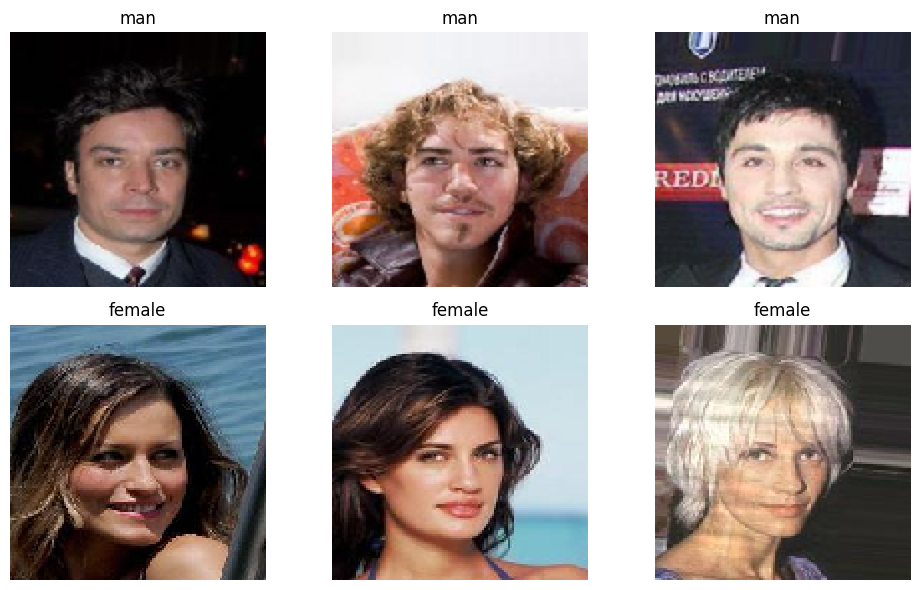

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

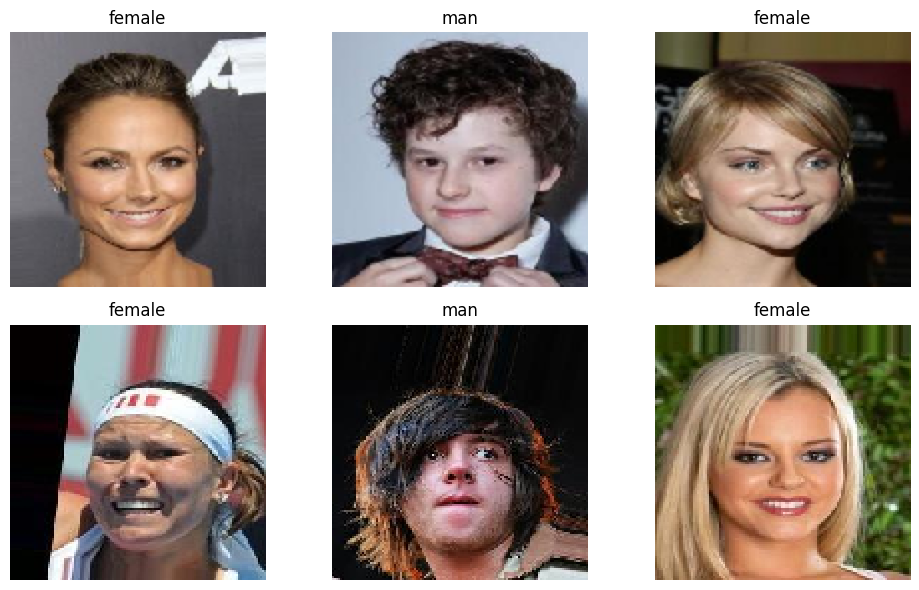

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img

IMAGE_SIZE = (128, 128)

plt.figure(figsize=(10, 6))

for i in range(6):
    sample = random.choice(df.index)
    filename = df.loc[sample, 'filename']
    category = df.loc[sample, 'category']
    
    img_path = os.path.join(train_dir, filename)
    image = load_img(img_path, target_size=IMAGE_SIZE)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 4. Build Model

- First, copy VGG16 without the dense layers, use the weights from `imagenet`. Set the input shape to `(178,218,3)`.
- Freeze the layers except the last two layers and print to see if the layers are trainable or not.
- Build your sequential model (you are free to use a functioanl API as a further exercise). Include all the frozen VGG layers to your model. Add a Dense layer with 128 inouts and `relu` activation. Add a batch nomalizer, then a dense layer as the output layer. 
- Create an early stopping criteria monitorin the loss value for the validation set. Stop the search if the loss value deosnt change for two consecutive times.
- Compile the model.
- Save the best model automatically based on the performance of the validation set.

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

INPUT_SHAPE = (178, 218, 3)

class_mode="binary"

# VGG16 base
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE
)

# Freeze all layers
for layer in vgg_base.layers:
    layer.trainable = False

# Unfreeze last two layers with weights
unfroze = 0
for layer in reversed(vgg_base.layers):
    if layer.weights:
        layer.trainable = True
        unfroze += 1
        if unfroze == 2:
            break

# Verify trainability
for i, layer in enumerate(vgg_base.layers):
    print(f"{i:02d} {layer.name:25s} trainable={layer.trainable}")

# Explicit input layer
# 'This makes the model immediately callable and avoids a lot of “undefined output” issues.'
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, BatchNormalization

INPUT_SHAPE = (178, 218, 3)


# Build Sequential model
model = Sequential([
    vgg_base,
    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dense(1, activation="sigmoid")   # categorical output
])

# Callbacks
earlystop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="model.celeb_man_female.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

00 input_layer_2             trainable=False
01 block1_conv1              trainable=False
02 block1_conv2              trainable=False
03 block1_pool               trainable=False
04 block2_conv1              trainable=False
05 block2_conv2              trainable=False
06 block2_pool               trainable=False
07 block3_conv1              trainable=False
08 block3_conv2              trainable=False
09 block3_conv3              trainable=False
10 block3_pool               trainable=False
11 block4_conv1              trainable=False
12 block4_conv2              trainable=False
13 block4_conv3              trainable=False
14 block4_pool               trainable=False
15 block5_conv1              trainable=False
16 block5_conv2              trainable=True
17 block5_conv3              trainable=True
18 block5_pool               trainable=False


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 5, 6, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 15360)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,966,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,681,537 (63.64 MB)

 Trainable params: 6,686,209 (25.51 MB)

 Non-trainable params: 9,995,328 (38.13 MB)

## 5. Data Preparation

- Create a validation set with 20% of the data. Check the number of data points per class from both the train and validation sets.
- Set your batch size to 20.
- Create the data generator and set the `preprocessing_function` to `preprocess_input` of VGG16.
- Create train and validation data generators (batches will be picked up from the dataframe). Set target size to (178,218) (you can try something else, but you need to do the corresponding change in the model).
- Set your validation  and epoch step size (`validation_steps` and `steps_per_epoch`)

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# 1) Train/Validation split (20% validation)
train_df, valid_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]  # keeps class balance consistent
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)

print("\nTrain class counts:")
print(train_df["category"].value_counts())

print("\nValid class counts:")
print(valid_df["category"].value_counts())

# 2) Batch size
BATCH_SIZE = 20

# 3) Image generators (use VGG16 preprocess_input)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

valid_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# 4) Flow from dataframe
TARGET_SIZE = (178, 218)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",      # two classes -> simplest
    shuffle=True
)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory=train_dir,
    x_col="filename",
    y_col="category",
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nclass_indices:", train_generator.class_indices)

# 5) Steps per epoch / validation steps
steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = valid_generator.n // valid_generator.batch_size

# If you want to ensure you don't drop the last partial batch, use ceil:
# import math
# steps_per_epoch = math.ceil(train_generator.n / train_generator.batch_size)
# validation_steps = math.ceil(valid_generator.n / valid_generator.batch_size)

print("\nsteps_per_epoch:", steps_per_epoch)
print("validation_steps:", validation_steps)


Train shape: (3040, 2)
Valid shape: (761, 2)

Train class counts:
category
female    1527
man       1513
Name: count, dtype: int64

Valid class counts:
category
female    382
man       379
Name: count, dtype: int64
Found 3040 validated image filenames belonging to 2 classes.
Found 761 validated image filenames belonging to 2 classes.

class_indices: {'female': 0, 'man': 1}

steps_per_epoch: 152
validation_steps: 38


## 6. Train the Model

- Fit the model
- save the model

In [24]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=[earlystop, checkpoint],
    verbose=1
)

Epoch 1/30


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8538 - loss: 0.3276
Epoch 1: val_loss improved from inf to 0.33400, saving model to model.celeb_man_female.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 299s 2s/step - accuracy: 0.8540 - loss: 0.3271 - val_accuracy: 0.8697 - val_loss: 0.3340
Epoch 2/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9653 - loss: 0.1027
Epoch 2: val_loss improved from 0.33400 to 0.30617, saving model to model.celeb_man_female.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.9653 - loss: 0.1027 - val_accuracy: 0.8737 - val_loss: 0.3062
Epoch 3/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9706 - loss: 0.1026
Epoch 3: val_loss improved from 0.30617 to 0.12333, saving model to model.celeb_man_female.keras
152/152 ━━━━━━━━━━━━━━━━━━━━ 354s 2s/step - accuracy: 0.9705 - loss: 0.1026 - val_accuracy: 0.9553 - val_loss: 0.1233
Epoch 4/30
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9788 - loss: 0.0680
Epoch 4: val_loss did not impr

Patience is set = 2, so it will stop after 2 consecutive epochs with no improvement.

In [ ]:
# Save model
model.save("model.celeb_man_female.keras")

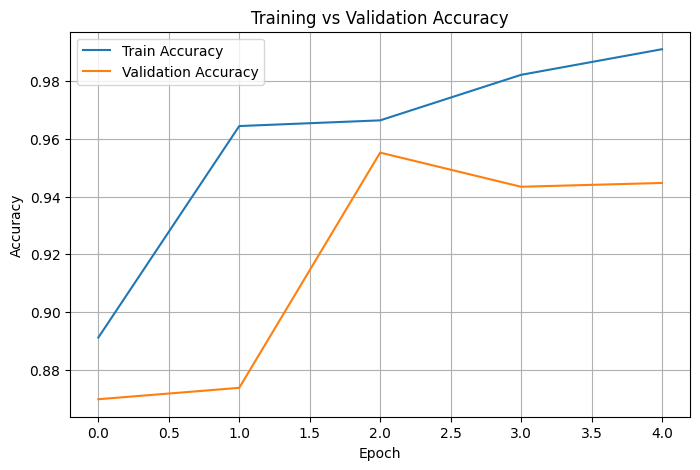

In [25]:
# Plot Accuracy by Epoch
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


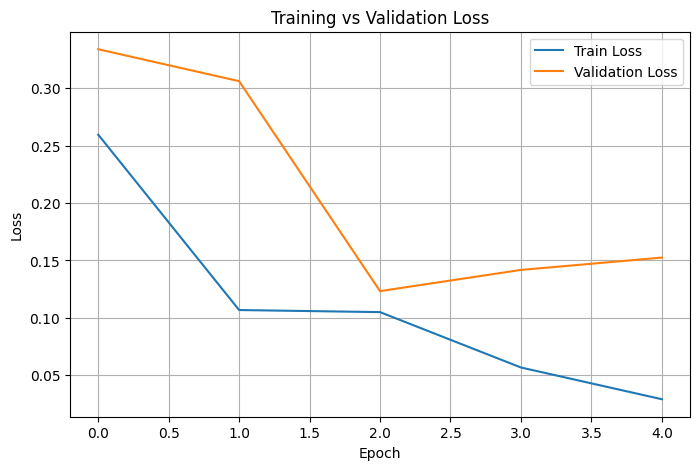

In [26]:
# Plot Loss by Epoch
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Build dataframe comparing predictions with correctness and confidence
import math
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input

# Make a stable copy in a known order
df_pred = df.copy().reset_index(drop=True)

BATCH_SIZE = 20
TARGET_SIZE = (178, 218)  # must match training

pred_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Important: shuffle=False so predictions line up with df_pred row-for-row
pred_gen = pred_datagen.flow_from_dataframe(
    dataframe=df_pred,
    directory=train_dir,
    x_col="filename",
    y_col="category",     # keep y so we get class_indices and can compute correctness
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",  # OK even if model is softmax; we only use it for labels & class_indices
    shuffle=False
)

steps = math.ceil(pred_gen.n / pred_gen.batch_size)

# Predict
yhat = model.predict(pred_gen, steps=steps, verbose=1)

# Convert model outputs to P(man) robustly:
# - sigmoid model => shape (n,1)
# - softmax model => shape (n,2)
class_indices = pred_gen.class_indices          # e.g. {'female': 0, 'man': 1}
idx_man = class_indices.get("man", 1)           # fallback if keys differ

if yhat.ndim == 2 and yhat.shape[1] == 1:
    # sigmoid
    p_man = yhat[:, 0]
elif yhat.ndim == 2 and yhat.shape[1] == 2:
    # softmax
    p_man = yhat[:, idx_man]
else:
    raise ValueError(f"Unexpected prediction shape: {yhat.shape}")

# Predicted label + confidence
df_pred["p_man"] = p_man
df_pred["p_female"] = 1 - p_man
df_pred["pred_category"] = np.where(df_pred["p_man"] >= 0.5, "man", "female")
df_pred["pred_confidence"] = np.maximum(df_pred["p_man"], df_pred["p_female"])

# Compare to actual
df_pred["correct"] = (df_pred["pred_category"] == df_pred["category"]).astype(int)

# Quick summary
print(df_pred[["category", "pred_category", "correct"]].value_counts())
print("Accuracy:", df_pred["correct"].mean())

df_pred.head()


Found 3801 validated image filenames belonging to 2 classes.


/opt/anaconda3/envs/IOD2/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


191/191 ━━━━━━━━━━━━━━━━━━━━ 450s 2s/step
category  pred_category  correct
man       man            1          1883
female    female         1          1854
          man            0            55
man       female         0             9
Name: count, dtype: int64
Accuracy: 0.9831623257037622


,filename,category,p_man,p_female,pred_category,pred_confidence,correct
0,female.026413.jpg,female,0.028154,0.971846,female,0.971846,1
1,female.022675.jpg,female,0.013337,0.986663,female,0.986663,1
2,man.033406.jpg,man,0.999997,0.000003,man,0.999997,1
3,man.033360.jpg,man,0.982813,0.017187,man,0.982813,1
4,female.020704.jpg,female,0.000631,0.999370,female,0.999370,1


In [29]:
df_pred['category'].value_counts()

category
female    1909
man       1892
Name: count, dtype: int64

In [30]:
df_pred['correct'].value_counts()

correct
1    3737
0      64
Name: count, dtype: int64

In [38]:
men_as_women = ((df_pred["category"] == "man") &
                (df_pred["pred_category"] == "female")).sum()

women_as_men = ((df_pred["category"] == "female") &
                (df_pred["pred_category"] == "man")).sum()


median_conf_man_as_woman = df_pred.loc[
    (df_pred["category"] == "man") &
    (df_pred["pred_category"] == "female"),
    "pred_confidence"
].median()

median_conf_woman_as_man = df_pred.loc[
    (df_pred["category"] == "female") &
    (df_pred["pred_category"] == "man"),
    "pred_confidence"
].median()



print("Men predicted as women:", men_as_women)
print(f"Median confidence of men predicted as women: {median_conf_man_as_woman:.3f}")
print("Women predicted as men:", women_as_men)
print(f"Median confidence of women predicted as men: {median_conf_woman_as_man:.3f}")

print("Median confidence of all correct predictions:",
      df_pred.loc[df_pred["correct"] == 1, "pred_confidence"].median())

print("Median confidence of all incorrect predictions:",
      df_pred.loc[df_pred["correct"] == 0, "pred_confidence"].median())

Men predicted as women: 9
Median confidence of men predicted as women: 0.760
Women predicted as men: 55
Median confidence of women predicted as men: 0.678
Median confidence of all correct predictions: 0.99861336
Median confidence of all incorrect predictions: 0.68046814


What was the most confident incorrect image?

In [44]:
most_confident_wrong = (
    df_pred
    .loc[df_pred["correct"] == 0]
    .sort_values("pred_confidence", ascending=False)
    .iloc[0]
)

most_confident_wrong

filename           female.011941.jpg
category                      female
p_man                        0.99941
p_female                     0.00059
pred_category                    man
pred_confidence              0.99941
correct                            0
Name: 1985, dtype: object

Let's see it.

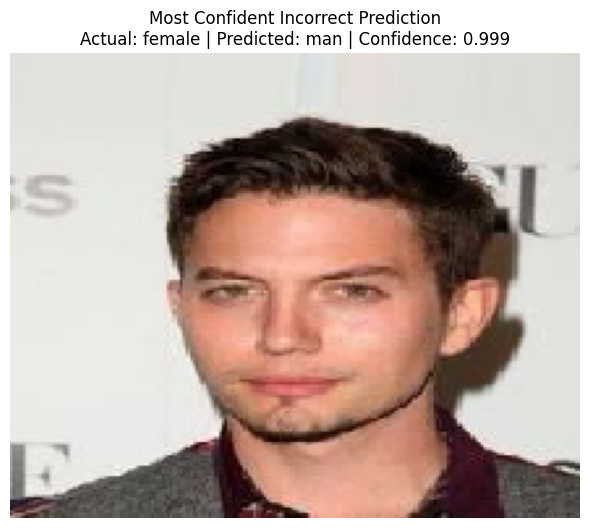

In [45]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import os

# Recompute the row explicitly
row = (
    df_pred[df_pred["correct"] == 0]
    .sort_values("pred_confidence", ascending=False)
    .iloc[0]
)

img_path = os.path.join(train_dir, row["filename"])
img = load_img(img_path, target_size=(178, 218))

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Most Confident Incorrect Prediction\n"
    f"Actual: {row['category']} | "
    f"Predicted: {row['pred_category']} | "
    f"Confidence: {row['pred_confidence']:.3f}"
)
plt.tight_layout()
plt.show()


What was the least confident prediction?

In [55]:
least_confident = (
    df_pred
    .sort_values("pred_confidence", ascending=True)
    .iloc[0]
)

least_confident

filename           female.021888.jpg
category                      female
p_man                       0.507313
p_female                    0.492687
pred_category                    man
pred_confidence             0.507313
correct                            0
brightness                 43.427559
Name: 1274, dtype: object

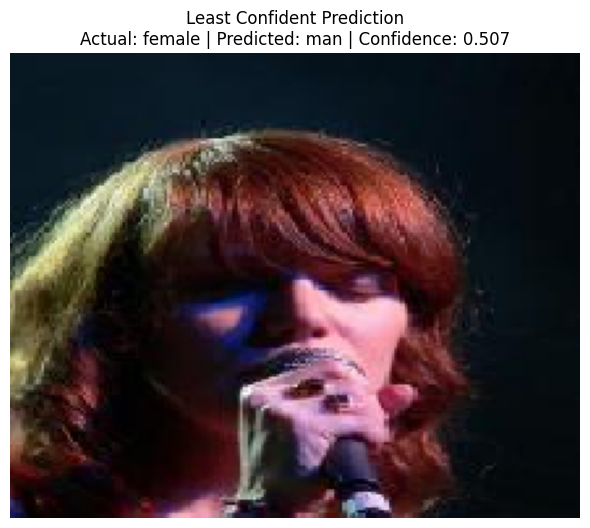

In [56]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import os

# Get the least-confident prediction
row = (
    df_pred
    .sort_values("pred_confidence", ascending=True)
    .iloc[0]
)

img_path = os.path.join(train_dir, row["filename"])
img = load_img(img_path, target_size=(178, 218))

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Least Confident Prediction\n"
    f"Actual: {row['category']} | "
    f"Predicted: {row['pred_category']} | "
    f"Confidence: {row['pred_confidence']:.3f}"
)
plt.tight_layout()
plt.show()

# IDEAS FOR LATER

Find a way to see correlation of features with accuracy, broken down with both male and female.

What if I swapped file names and intentionally misled a model on labels? Or would it just learn the new features and assign them to the "incorrect" labels? Maybe I could use the same model, trained on "real" data, on "fake" data? Is that just dicking around?

In [46]:
import numpy as np
from PIL import Image

def avg_brightness(path):
    img = Image.open(path).convert("L")
    return np.array(img).mean()

df_pred["brightness"] = df_pred["filename"].apply(
    lambda f: avg_brightness(os.path.join(train_dir, f))
)

df_pred.groupby("correct")["brightness"].describe()


,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
0,64.0,113.191477,41.840112,33.996109,83.154114,109.382602,150.536820,203.344784
1,3737.0,113.190454,36.242530,26.297469,85.379265,111.806077,139.400809,221.677224


In [49]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

last_conv_layer_name = "block5_conv3"

# Get the conv layer from inside VGG16
last_conv_layer = vgg_base.get_layer(last_conv_layer_name)

_ = model(tf.zeros((1, 178, 218, 3)))

# Build Grad-CAM model
grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[last_conv_layer.output, model.output]
)

def make_gradcam_heatmap(img_array):
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()


AttributeError: The layer sequential_1 has never been called and thus has no defined output.